In [1]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.6.0+cu124
CUDA available: True
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [2]:
import os

print(os.listdir("newDataset"))

['Bargur', 'Gir', 'Hallikar', 'Ongole', 'Tharparkar']


In [3]:
from pathlib import Path

for breed in Path("newDataset").iterdir():
    if breed.is_dir():
        count = len(list(breed.glob("*")))
        print(breed.name, ":", count)

Bargur : 470
Gir : 7
Hallikar : 1951
Ongole : 343
Tharparkar : 814


In [4]:
import os

print(os.listdir("newDataset/Gir"))

['gircow1', 'gircow2', 'gircow3', 'gircow4', 'gircow5', 'gircow6', 'gircow7']


In [5]:
from pathlib import Path

gir_images = list(Path("newDataset/Gir").rglob("*"))
gir_images = [x for x in gir_images if x.is_file()]

print("Gir images:", len(gir_images))

Gir images: 3648


In [6]:
from pathlib import Path

for breed in Path("newDataset").iterdir():
    if breed.is_dir():
        images = [x for x in breed.rglob("*") if x.is_file()]
        print(breed.name, ":", len(images))

Bargur : 470
Gir : 3648
Hallikar : 1951
Ongole : 343
Tharparkar : 814


In [7]:
breed_counts = {
    "Bargur": 470,
    "Gir": 3648,
    "Hallikar": 1951,
    "Ongole": 343,
    "Tharparkar": 814
}

print(breed_counts)

{'Bargur': 470, 'Gir': 3648, 'Hallikar': 1951, 'Ongole': 343, 'Tharparkar': 814}


In [8]:
total_images = sum(breed_counts.values())

print("Total images:", total_images)

Total images: 7226


In [9]:
for breed, count in breed_counts.items():
    percentage = (count / total_images) * 100
    print(breed, ":", round(percentage, 2), "%")

Bargur : 6.5 %
Gir : 50.48 %
Hallikar : 27.0 %
Ongole : 4.75 %
Tharparkar : 11.26 %


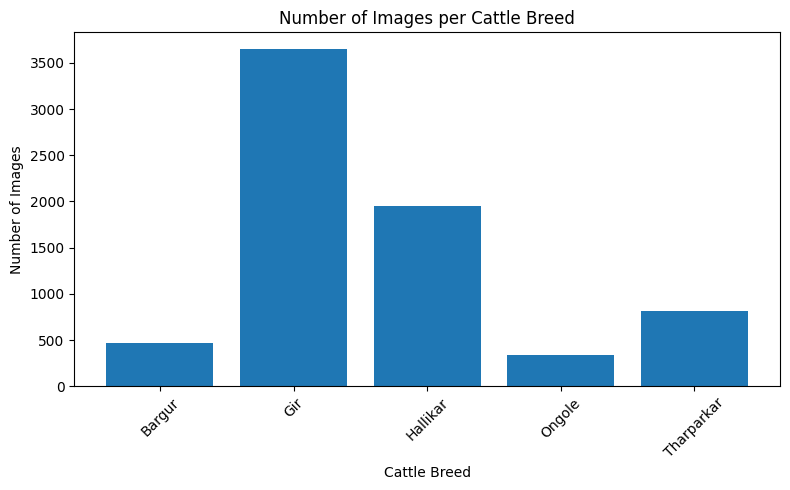

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(breed_counts.keys(), breed_counts.values())
plt.xlabel("Cattle Breed")
plt.ylabel("Number of Images")
plt.title("Number of Images per Cattle Breed")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
from PIL import Image

image_path = next(Path("newDataset/Bargur").rglob("*"))
print("Image:", image_path)

img = Image.open(image_path)
print("Size:", img.size)
print("Format:", img.format)

Image: newDataset\Bargur\Bargur (10).jpg
Size: (800, 600)
Format: JPEG


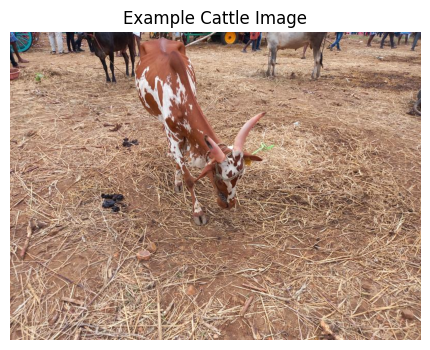

In [12]:
plt.figure(figsize=(6, 4))
plt.imshow(img)
plt.axis("off")
plt.title("Example Cattle Image")
plt.show()

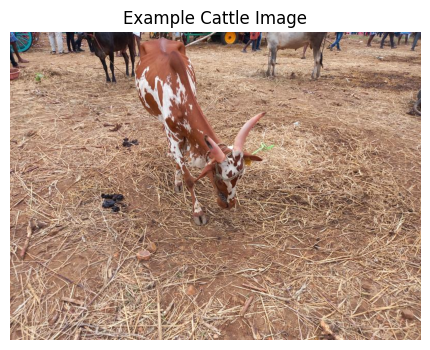

In [13]:
plt.figure(figsize=(6, 4))
plt.imshow(img)
plt.axis("off")
plt.title("Example Cattle Image")
plt.show()

In [15]:
import pandas
import sklearn
import PIL
import matplotlib
import seaborn

print("All libraries are working!")

All libraries are working!


In [16]:
from torchvision import datasets, transforms

dataset = datasets.ImageFolder("newDataset")

print("Classes:", dataset.classes)
print("Number of images:", len(dataset))

Classes: ['Bargur', 'Gir', 'Hallikar', 'Ongole', 'Tharparkar']
Number of images: 7226


In [17]:
print(dataset.class_to_idx)

{'Bargur': 0, 'Gir': 1, 'Hallikar': 2, 'Ongole': 3, 'Tharparkar': 4}


In [18]:
from sklearn.model_selection import train_test_split

indices = list(range(len(dataset)))
labels = [label for _, label in dataset.samples]

train_idx, temp_idx = train_test_split(
    indices,
    test_size=0.30,
    stratify=labels,
    random_state=42
)

temp_labels = [labels[i] for i in temp_idx]

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    stratify=temp_labels,
    random_state=42
)

print("Training images:", len(train_idx))
print("Validation images:", len(val_idx))
print("Test images:", len(test_idx))

Training images: 5058
Validation images: 1084
Test images: 1084


In [19]:
print("Total:", len(dataset))
print("Train:", len(train_idx))
print("Validation:", len(val_idx))
print("Test:", len(test_idx))
print("Sum:", len(train_idx) + len(val_idx) + len(test_idx))

Total: 7226
Train: 5058
Validation: 1084
Test: 1084
Sum: 7226


In [20]:
from collections import Counter

train_labels = [labels[i] for i in train_idx]

print(Counter(train_labels))

Counter({1: 2553, 2: 1366, 4: 570, 0: 329, 3: 240})


In [21]:
val_labels = [labels[i] for i in val_idx]
test_labels = [labels[i] for i in test_idx]

print("Validation:", Counter(val_labels))
print("Test:", Counter(test_labels))

Validation: Counter({1: 548, 2: 293, 4: 122, 0: 70, 3: 51})
Test: Counter({1: 547, 2: 292, 4: 122, 0: 71, 3: 52})


In [22]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

print("Transforms created successfully!")

Transforms created successfully!


In [23]:
train_dataset = datasets.ImageFolder(
    "newDataset",
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    "newDataset",
    transform=test_transform
)

test_dataset = datasets.ImageFolder(
    "newDataset",
    transform=test_transform
)

print("Datasets created successfully!")

Datasets created successfully!


In [24]:
from torch.utils.data import DataLoader, Subset

train_subset = Subset(train_dataset, train_idx)
val_subset = Subset(val_dataset, val_idx)
test_subset = Subset(test_dataset, test_idx)

train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_subset, batch_size=32, shuffle=False)

print("Data loaders created successfully!")

Data loaders created successfully!


In [25]:
images, batch_labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", batch_labels.shape)

Images shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])


In [26]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using:", device)

Using: cuda


In [27]:
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x

print("CNN model created successfully!")

CNN model created successfully!


In [28]:
model = SimpleCNN(num_classes=5).to(device)

print(model)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=128, out_features=64, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=64, out_features=5, bias=True)
  )
)


In [29]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Loss function and optimizer created!")

Loss function and optimizer created!


In [30]:
from pathlib import Path

for breed in Path("newDataset").iterdir():
    if breed.is_dir():
        subfolders = [p.name for p in breed.iterdir() if p.is_dir()]
        print(breed.name, "->", len(subfolders), "subfolders")
        print(subfolders[:10])
        

Bargur -> 0 subfolders
[]
Gir -> 7 subfolders
['gircow1', 'gircow2', 'gircow3', 'gircow4', 'gircow5', 'gircow6', 'gircow7']
Hallikar -> 0 subfolders
[]
Ongole -> 0 subfolders
[]
Tharparkar -> 0 subfolders
[]


In [31]:
from pathlib import Path

gir_path = Path("newDataset/Gir")

for cow_folder in sorted(gir_path.iterdir()):
    if cow_folder.is_dir():
        images = [p for p in cow_folder.rglob("*") if p.is_file()]
        print(cow_folder.name, ":", len(images), "images")

gircow1 : 503 images
gircow2 : 501 images
gircow3 : 500 images
gircow4 : 500 images
gircow5 : 500 images
gircow6 : 500 images
gircow7 : 644 images


In [32]:
for cow_folder in sorted(Path("newDataset/Gir").iterdir()):
    if cow_folder.is_dir():
        cow_indices = [
            i for i, (path, label) in enumerate(dataset.samples)
            if Path(path).parent.name == cow_folder.name
        ]

        train_count = sum(i in train_idx for i in cow_indices)
        val_count = sum(i in val_idx for i in cow_indices)
        test_count = sum(i in test_idx for i in cow_indices)

        print(
            cow_folder.name,
            "-> Train:", train_count,
            "Validation:", val_count,
            "Test:", test_count
        )

gircow1 -> Train: 344 Validation: 86 Test: 73
gircow2 -> Train: 354 Validation: 74 Test: 73
gircow3 -> Train: 363 Validation: 65 Test: 72
gircow4 -> Train: 357 Validation: 62 Test: 81
gircow5 -> Train: 363 Validation: 74 Test: 63
gircow6 -> Train: 338 Validation: 86 Test: 76
gircow7 -> Train: 434 Validation: 101 Test: 109


In [33]:
# Create a new split that keeps each Gir cow in only one split

gir_train_cows = {"gircow1", "gircow2", "gircow3", "gircow4", "gircow5"}
gir_val_cows = {"gircow6"}
gir_test_cows = {"gircow7"}

new_train_idx = []
new_val_idx = []
new_test_idx = []

for i, (path, label) in enumerate(dataset.samples):
    path_obj = Path(path)

    if label == dataset.class_to_idx["Gir"]:
        cow = path_obj.parent.name

        if cow in gir_train_cows:
            new_train_idx.append(i)
        elif cow in gir_val_cows:
            new_val_idx.append(i)
        elif cow in gir_test_cows:
            new_test_idx.append(i)
    else:
        if i in train_idx:
            new_train_idx.append(i)
        elif i in val_idx:
            new_val_idx.append(i)
        elif i in test_idx:
            new_test_idx.append(i)

print("New Train:", len(new_train_idx))
print("New Validation:", len(new_val_idx))
print("New Test:", len(new_test_idx))

New Train: 5009
New Validation: 1036
New Test: 1181


In [34]:
# Convert the old split lists to sets for reliable checking
train_set = set(train_idx)
val_set = set(val_idx)
test_set = set(test_idx)

new_train_idx = []
new_val_idx = []
new_test_idx = []

for i, (path, label) in enumerate(dataset.samples):
    path_obj = Path(path)

    if label == dataset.class_to_idx["Gir"]:
        cow = path_obj.parent.name

        if cow in {"gircow1", "gircow2", "gircow3", "gircow4", "gircow5"}:
            new_train_idx.append(i)
        elif cow == "gircow6":
            new_val_idx.append(i)
        elif cow == "gircow7":
            new_test_idx.append(i)

    else:
        if i in train_set:
            new_train_idx.append(i)
        elif i in val_set:
            new_val_idx.append(i)
        elif i in test_set:
            new_test_idx.append(i)

print("New Train:", len(new_train_idx))
print("New Validation:", len(new_val_idx))
print("New Test:", len(new_test_idx))
print("Total:", len(new_train_idx) + len(new_val_idx) + len(new_test_idx))

New Train: 5009
New Validation: 1036
New Test: 1181
Total: 7226


In [35]:
train_subset = Subset(train_full, new_train_idx)
val_subset = Subset(eval_full, new_val_idx)
test_subset = Subset(eval_full, new_test_idx)

train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_subset, batch_size=32, shuffle=False)

print("Data loaders updated successfully!")

NameError: name 'train_full' is not defined

In [36]:
train_full = datasets.ImageFolder(
    "newDataset",
    transform=train_transform
)

eval_full = datasets.ImageFolder(
    "newDataset",
    transform=test_transform
)

print("Full datasets created successfully!")

Full datasets created successfully!


In [37]:
train_subset = Subset(train_full, new_train_idx)
val_subset = Subset(eval_full, new_val_idx)
test_subset = Subset(eval_full, new_test_idx)

train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_subset, batch_size=32, shuffle=False)

print("Data loaders updated successfully!")

Data loaders updated successfully!


In [40]:
model.train()

for images, labels_batch in train_loader:
    images = images.to(device)
    labels_batch = labels_batch.to(device)

    optimizer.zero_grad()

    outputs = model(images)
    loss = criterion(outputs, labels_batch)

    loss.backward()
    optimizer.step()

print("1 training epoch completed successfully!")

1 training epoch completed successfully!


In [42]:
model = SimpleCNN(num_classes=5).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("CNN reset and ready for training!")

CNN reset and ready for training!


In [43]:
num_epochs = 5

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):

    # Training
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels_batch in train_loader:
        images = images.to(device)
        labels_batch = labels_batch.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels_batch)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels_batch.size(0)
        correct += (predicted == labels_batch).sum().item()

    train_loss = running_loss / len(train_loader.dataset)
    train_accuracy = correct / total

    # Validation
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels_batch in val_loader:
            images = images.to(device)
            labels_batch = labels_batch.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels_batch)

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels_batch.size(0)
            correct += (predicted == labels_batch).sum().item()

    val_loss = running_loss / len(val_loader.dataset)
    val_accuracy = correct / total

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f}"
    )

Epoch 1/5 | Train Loss: 1.3057 | Train Acc: 0.4925 | Val Loss: 1.3047 | Val Acc: 0.4826
Epoch 2/5 | Train Loss: 1.1340 | Train Acc: 0.5376 | Val Loss: 1.2677 | Val Acc: 0.4093
Epoch 3/5 | Train Loss: 1.0286 | Train Acc: 0.6271 | Val Loss: 1.0509 | Val Acc: 0.6371
Epoch 4/5 | Train Loss: 0.8250 | Train Acc: 0.7095 | Val Loss: 1.0725 | Val Acc: 0.6236
Epoch 5/5 | Train Loss: 0.6545 | Train Acc: 0.7606 | Val Loss: 0.9480 | Val Acc: 0.6718


In [44]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():
    for images, labels_batch in test_loader:
        images = images.to(device)

        outputs = model(images)
        predictions = torch.argmax(outputs, dim=1)

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels_batch.numpy())

test_accuracy = accuracy_score(all_labels, all_predictions)
test_macro_f1 = f1_score(
    all_labels,
    all_predictions,
    average="macro"
)

print("Test Accuracy:", round(test_accuracy, 4))
print("Test Macro F1:", round(test_macro_f1, 4))

print("\nClassification Report:")
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=dataset.classes
    )
)

Test Accuracy: 0.6325
Test Macro F1: 0.4761

Classification Report:
              precision    recall  f1-score   support

      Bargur       0.56      0.72      0.63        71
         Gir       0.76      0.60      0.67       644
    Hallikar       0.57      0.96      0.71       292
      Ongole       0.50      0.06      0.10        52
  Tharparkar       0.33      0.22      0.26       122

    accuracy                           0.63      1181
   macro avg       0.54      0.51      0.48      1181
weighted avg       0.64      0.63      0.61      1181



In [45]:
baseline_results = {
    "Test Accuracy": test_accuracy,
    "Test Macro F1": test_macro_f1
}

print(baseline_results)

{'Test Accuracy': 0.632514817950889, 'Test Macro F1': 0.4761434519303556}


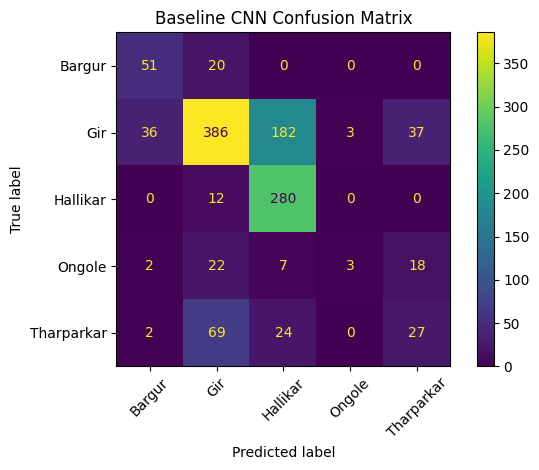

In [46]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    all_labels,
    all_predictions,
    display_labels=dataset.classes,
    xticks_rotation=45
)

plt.title("Baseline CNN Confusion Matrix")
plt.tight_layout()
plt.show()

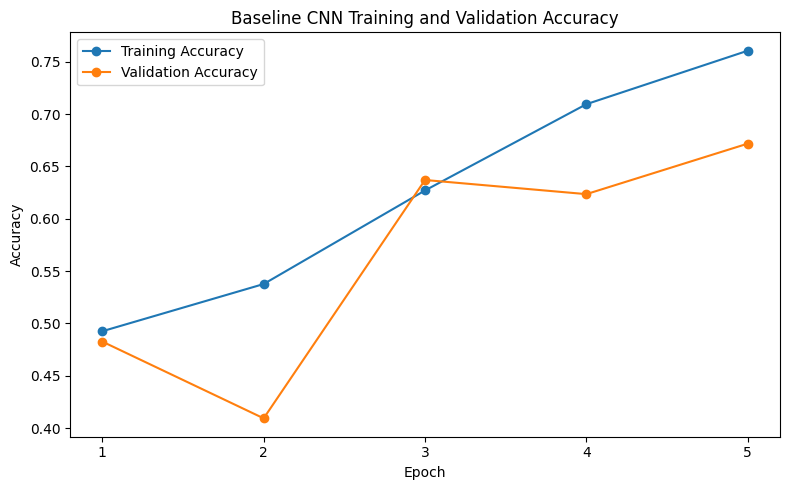

In [47]:
plt.figure(figsize=(8, 5))

plt.plot(range(1, 6), train_accuracies, marker="o", label="Training Accuracy")
plt.plot(range(1, 6), val_accuracies, marker="o", label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline CNN Training and Validation Accuracy")
plt.xticks(range(1, 6))
plt.legend()
plt.tight_layout()
plt.show()

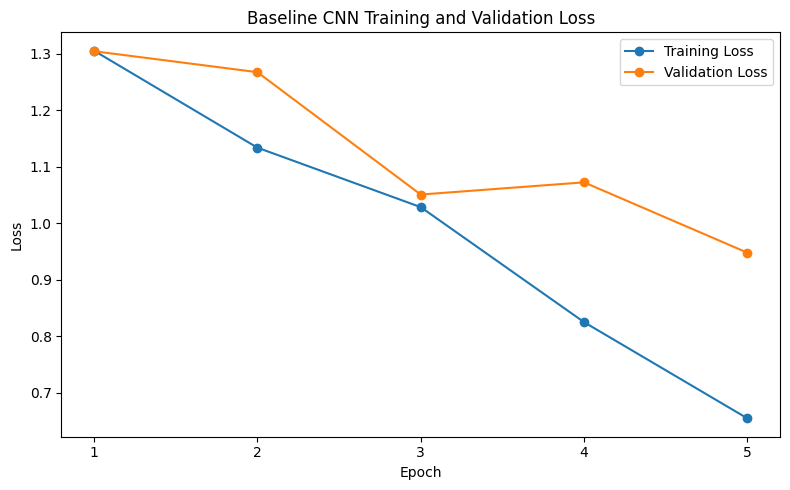

In [48]:
plt.figure(figsize=(8, 5))

plt.plot(range(1, 6), train_losses, marker="o", label="Training Loss")
plt.plot(range(1, 6), val_losses, marker="o", label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline CNN Training and Validation Loss")
plt.xticks(range(1, 6))
plt.legend()
plt.tight_layout()
plt.show()

In [49]:
baseline_report = classification_report(
    all_labels,
    all_predictions,
    target_names=dataset.classes,
    output_dict=True
)

print("Baseline classification report saved.")

Baseline classification report saved.


In [50]:
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights

weights = MobileNet_V2_Weights.DEFAULT

transfer_model = mobilenet_v2(weights=weights)

transfer_model.classifier[1] = nn.Linear(
    transfer_model.last_channel,
    5
)

transfer_model = transfer_model.to(device)

print("Transfer-learning model created successfully!")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to C:\Users\srigo/.cache\torch\hub\checkpoints\mobilenet_v2-7ebf99e0.pth
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 13.6M/13.6M [00:00<00:00, 37.3MB/s]

Transfer-learning model created successfully!


In [51]:
train_transform_tl = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform_tl = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Transfer-learning transforms created successfully!")

Transfer-learning transforms created successfully!


In [52]:
train_full_tl = datasets.ImageFolder(
    "newDataset",
    transform=train_transform_tl
)

eval_full_tl = datasets.ImageFolder(
    "newDataset",
    transform=eval_transform_tl
)

print("Transfer-learning datasets created successfully!")

Transfer-learning datasets created successfully!


In [53]:
train_subset_tl = Subset(train_full_tl, new_train_idx)
val_subset_tl = Subset(eval_full_tl, new_val_idx)
test_subset_tl = Subset(eval_full_tl, new_test_idx)

train_loader_tl = DataLoader(train_subset_tl, batch_size=32, shuffle=True)
val_loader_tl = DataLoader(val_subset_tl, batch_size=32, shuffle=False)
test_loader_tl = DataLoader(test_subset_tl, batch_size=32, shuffle=False)

print("Transfer-learning data loaders created successfully!")

Transfer-learning data loaders created successfully!


In [54]:
for param in transfer_model.features.parameters():
    param.requires_grad = False

criterion_tl = nn.CrossEntropyLoss()

optimizer_tl = optim.Adam(
    transfer_model.classifier.parameters(),
    lr=0.001
)

print("MobileNetV2 is ready for training!")

MobileNetV2 is ready for training!


In [55]:
num_epochs_tl = 5

tl_train_losses = []
tl_val_losses = []
tl_train_accuracies = []
tl_val_accuracies = []

for epoch in range(num_epochs_tl):

    transfer_model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels_batch in train_loader_tl:
        images = images.to(device)
        labels_batch = labels_batch.to(device)

        optimizer_tl.zero_grad()

        outputs = transfer_model(images)
        loss = criterion_tl(outputs, labels_batch)

        loss.backward()
        optimizer_tl.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)

        total += labels_batch.size(0)
        correct += (predicted == labels_batch).sum().item()

    train_loss = running_loss / len(train_loader_tl.dataset)
    train_accuracy = correct / total

    transfer_model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels_batch in val_loader_tl:
            images = images.to(device)
            labels_batch = labels_batch.to(device)

            outputs = transfer_model(images)
            loss = criterion_tl(outputs, labels_batch)

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)

            total += labels_batch.size(0)
            correct += (predicted == labels_batch).sum().item()

    val_loss = running_loss / len(val_loader_tl.dataset)
    val_accuracy = correct / total

    tl_train_losses.append(train_loss)
    tl_val_losses.append(val_loss)
    tl_train_accuracies.append(train_accuracy)
    tl_val_accuracies.append(val_accuracy)

    print(
        f"Epoch {epoch+1}/5 | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f}"
    )

Epoch 1/5 | Train Loss: 0.5110 | Train Acc: 0.8622 | Val Loss: 0.2959 | Val Acc: 0.9537
Epoch 2/5 | Train Loss: 0.1641 | Train Acc: 0.9695 | Val Loss: 0.1885 | Val Acc: 0.9701
Epoch 3/5 | Train Loss: 0.1068 | Train Acc: 0.9794 | Val Loss: 0.1440 | Val Acc: 0.9768
Epoch 4/5 | Train Loss: 0.0790 | Train Acc: 0.9876 | Val Loss: 0.1109 | Val Acc: 0.9836
Epoch 5/5 | Train Loss: 0.0664 | Train Acc: 0.9888 | Val Loss: 0.1007 | Val Acc: 0.9836


In [56]:
transfer_model.eval()

tl_predictions = []
tl_labels = []

with torch.no_grad():
    for images, labels_batch in test_loader_tl:
        images = images.to(device)

        outputs = transfer_model(images)
        predictions = torch.argmax(outputs, dim=1)

        tl_predictions.extend(predictions.cpu().numpy())
        tl_labels.extend(labels_batch.numpy())

tl_test_accuracy = accuracy_score(tl_labels, tl_predictions)

tl_test_macro_f1 = f1_score(
    tl_labels,
    tl_predictions,
    average="macro"
)

print("MobileNetV2 Test Accuracy:", round(tl_test_accuracy, 4))
print("MobileNetV2 Test Macro F1:", round(tl_test_macro_f1, 4))

print("\nClassification Report:")
print(
    classification_report(
        tl_labels,
        tl_predictions,
        target_names=dataset.classes
    )
)

MobileNetV2 Test Accuracy: 0.9873
MobileNetV2 Test Macro F1: 0.9808

Classification Report:
              precision    recall  f1-score   support

      Bargur       1.00      1.00      1.00        71
         Gir       0.99      0.99      0.99       644
    Hallikar       0.99      1.00      0.99       292
      Ongole       0.94      0.98      0.96        52
  Tharparkar       0.98      0.93      0.96       122

    accuracy                           0.99      1181
   macro avg       0.98      0.98      0.98      1181
weighted avg       0.99      0.99      0.99      1181



In [57]:
transfer_results = {
    "Test Accuracy": tl_test_accuracy,
    "Test Macro F1": tl_test_macro_f1
}

print(transfer_results)

{'Test Accuracy': 0.9872988992379339, 'Test Macro F1': 0.9808238160145517}


In [58]:
comparison = {
    "Simple CNN": {
        "Test Accuracy": test_accuracy,
        "Test Macro F1": test_macro_f1
    },
    "MobileNetV2": {
        "Test Accuracy": tl_test_accuracy,
        "Test Macro F1": tl_test_macro_f1
    }
}

for model_name, results in comparison.items():
    print(model_name)
    print("  Test Accuracy:", round(results["Test Accuracy"], 4))
    print("  Test Macro F1:", round(results["Test Macro F1"], 4))

Simple CNN
  Test Accuracy: 0.6325
  Test Macro F1: 0.4761
MobileNetV2
  Test Accuracy: 0.9873
  Test Macro F1: 0.9808


In [59]:
transfer_report = classification_report(
    tl_labels,
    tl_predictions,
    target_names=dataset.classes,
    output_dict=True
)

print("Both model reports are saved.")

Both model reports are saved.


In [60]:
print("Breed Recall Comparison")
print("-" * 40)

for breed in dataset.classes:
    cnn_recall = baseline_report[breed]["recall"]
    tl_recall = transfer_report[breed]["recall"]

    print(
        f"{breed}: "
        f"CNN = {cnn_recall:.2%} | "
        f"MobileNetV2 = {tl_recall:.2%}"
    )

Breed Recall Comparison
----------------------------------------
Bargur: CNN = 71.83% | MobileNetV2 = 100.00%
Gir: CNN = 59.94% | MobileNetV2 = 99.22%
Hallikar: CNN = 95.89% | MobileNetV2 = 99.66%
Ongole: CNN = 5.77% | MobileNetV2 = 98.08%
Tharparkar: CNN = 22.13% | MobileNetV2 = 93.44%


In [61]:
recall_comparison = {
    "Breed": dataset.classes,
    "Simple CNN": [
        baseline_report[breed]["recall"] * 100
        for breed in dataset.classes
    ],
    "MobileNetV2": [
        transfer_report[breed]["recall"] * 100
        for breed in dataset.classes
    ]
}

recall_df = pd.DataFrame(recall_comparison)

recall_df

NameError: name 'pd' is not defined

In [62]:
import pandas as pd

recall_comparison = {
    "Breed": dataset.classes,
    "Simple CNN": [
        baseline_report[breed]["recall"] * 100
        for breed in dataset.classes
    ],
    "MobileNetV2": [
        transfer_report[breed]["recall"] * 100
        for breed in dataset.classes
    ]
}

recall_df = pd.DataFrame(recall_comparison)

recall_df

,Breed,Simple CNN,MobileNetV2
0,Bargur,71.830986,100.000000
1,Gir,59.937888,99.223602
2,Hallikar,95.890411,99.657534
3,Ongole,5.769231,98.076923
4,Tharparkar,22.131148,93.442623


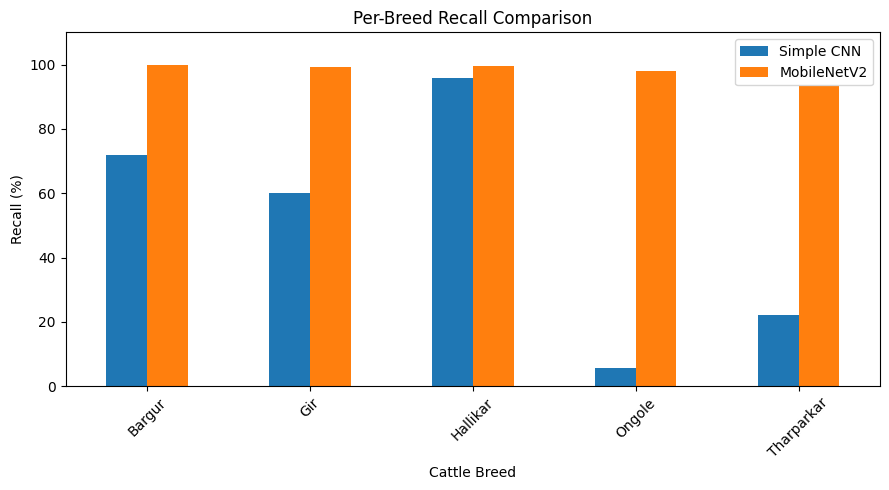

In [63]:
import matplotlib.pyplot as plt

recall_df.plot(
    x="Breed",
    y=["Simple CNN", "MobileNetV2"],
    kind="bar",
    figsize=(9, 5)
)

plt.ylabel("Recall (%)")
plt.xlabel("Cattle Breed")
plt.title("Per-Breed Recall Comparison")
plt.xticks(rotation=45)
plt.ylim(0, 110)
plt.tight_layout()
plt.show()

In [64]:
recall_df.to_csv("recall_comparison.csv", index=False)

print("Recall comparison saved.")

Recall comparison saved.


In [65]:
improvement = (
    transfer_results["Test Macro F1"]
    - baseline_results["Test Macro F1"]
)

print("Macro F1 improvement:", round(improvement, 4))
print("Macro F1 improvement (% points):", round(improvement * 100, 2))

Macro F1 improvement: 0.5047
Macro F1 improvement (% points): 50.47


In [1]:
model_comparison = pd.DataFrame({
    "Model": ["Simple CNN", "MobileNetV2"],
    "Test Accuracy": [
        baseline_results["Test Accuracy"] * 100,
        transfer_results["Test Accuracy"] * 100
    ],
    "Test Macro F1": [
        baseline_results["Test Macro F1"] * 100,
        transfer_results["Test Macro F1"] * 100
    ]
})

model_comparison

NameError: name 'pd' is not defined

In [2]:
import pandas as pd

model_comparison = pd.DataFrame({
    "Model": ["Simple CNN", "MobileNetV2"],
    "Test Accuracy": [63.25, 98.73],
    "Test Macro F1": [47.61, 98.08]
})

model_comparison

,Model,Test Accuracy,Test Macro F1
0,Simple CNN,63.25,47.61
1,MobileNetV2,98.73,98.08


In [3]:
model_comparison.to_csv("model_comparison.csv", index=False)

print("Model comparison saved.")

Model comparison saved.
